# A/B Testing in Mobile Games: Analyzing Player Retention in Cookie Cats

Cookie Cats, a widely popular mobile puzzle game by Tactile Entertainment, follows the classic "match-three" format, where players link tiles of the same color to clear the board and complete levels. As they advance, they encounter gates that either require a waiting period or an in-app purchase to proceed. This project examines the results of an A/B test that involved shifting the first gate from level 30 to level 40, focusing on its effect on player retention.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import pymc as pm
import warnings

from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


## Data

In [4]:
data = pd.read_csv("cookie_cats.csv")

In [5]:
data.head(5)

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


## Data Description
The dataset contains information on player rentention of a split test where the first gate in Cookie Cats was moved from level 30 to level 40. A total of 90,189 players installed the game while the A/B test was running. The variables are:

| Variable | Type | Description |
|----------|----------|----------|
| userid   | Integer  | A unique id that is given to each player   |
| version   | string   | Whether the player was put in the control group (gate_30 - a gate at level 30) or the group with the moved gate (gate_40 - a gate at level 40)   |
| sum_gamerounds   | Integer   | The number of game rounds played by the player during the first 14 days after install.   |
| retention_1   | boolean   | Did the player come back and play 1 day after installing?   |
| retention_7   | boolean  | Did the player come back and play 7 day after installing?   |

## Exploring the Data

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


There are no null values

In [7]:
data.version.value_counts()

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

There are balanced

In [8]:
data.sum_gamerounds.describe()

count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64

Text(0.5, 1.0, 'Game rounds played during first 14 days')

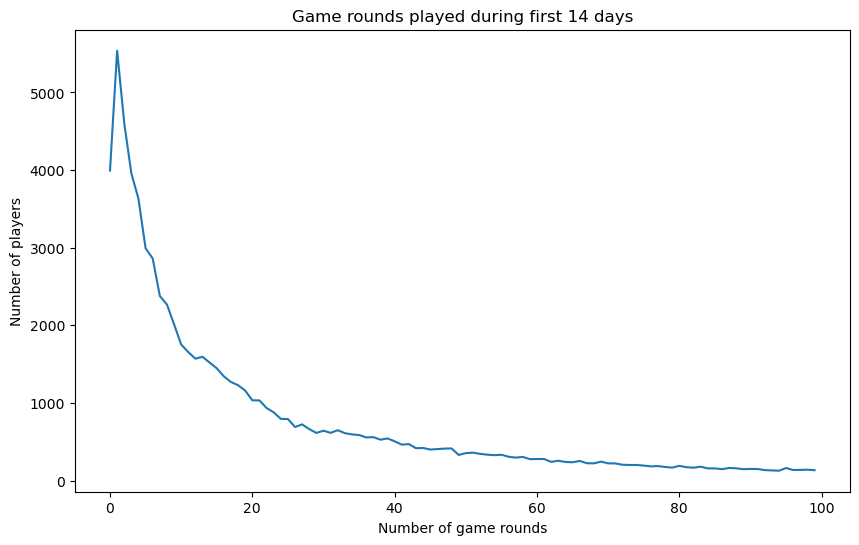

In [9]:
# Plotting distribution of game rounds
df = data.groupby('sum_gamerounds').count().reset_index()
plt.figure(figsize=(10,6))
ax = sns.lineplot(x='sum_gamerounds', y='userid', data=df.head(n=100))
ax.set_xlabel('Number of game rounds')
ax.set_ylabel('Number of players')
ax.set_title('Game rounds played during first 14 days')

Most players play few rounds, while a small group plays many. This suggests retention challenges atleast for the first 14 days. 

## Does playing more rounds increases chance of retention?

In [21]:
# Calculate the averages
retention_1_avg = data.groupby('retention_1')['sum_gamerounds'].mean()
retention_7_avg = data.groupby('retention_7')['sum_gamerounds'].mean()

# Replace True/False with Retained/Not Retained using map
retention_1_avg.index = retention_1_avg.index.map({True: 'Retained', False: 'Not Retained'})
retention_7_avg.index = retention_7_avg.index.map({True: 'Retained', False: 'Not Retained'})

In [22]:
average_game_rounds = pd.DataFrame({
    'Retention Day 1': retention_1_avg,
    'Retention Day 7': retention_7_avg
}).reset_index()

styled_table = average_game_rounds.style.set_table_styles(
    [{'selector': 'thead th', 'props': [('background-color', '#f4f4f4'), ('color', 'black'), ('font-weight', 'bold')]},
     {'selector': 'tbody td', 'props': [('text-align', 'center')]},
     {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('width', '50%')]},
     {'selector': 'th, td', 'props': [('padding', '8px'), ('border', '1px solid #ddd')]}]
)

styled_table

,index,Retention Day 1,Retention Day 7
0,Not Retained,17.345651,25.826844
1,Retained,94.897467,165.808236


Players who return on Day 1 played ~95 rounds on average, while those who didn’t played only ~17 rounds.

Players who return on Day 7 played ~166 rounds on average, while those who didn’t played only ~26 rounds.

Retained players have significantly higher game rounds than non-retained players, this might mean that playing more rounds increases retention.

In [23]:
corr_1 = data[['sum_gamerounds', 'retention_1']].corr().iloc[0,1]
corr_7 = data[['sum_gamerounds', 'retention_7']].corr().iloc[0,1]

print(f"Correlation between Game Rounds and Day 1 Retention: {corr_1:.4f}")
print(f"Correlation between Game Rounds and Day 7 Retention: {corr_7:.4f}")

Correlation between Game Rounds and Day 1 Retention: 0.1976
Correlation between Game Rounds and Day 7 Retention: 0.2793


In [27]:
warnings.simplefilter(action='ignore', category=UserWarning)

bins = [0, 10, 50, 100, 500, data['sum_gamerounds'].max()] 
labels = ['0-10', '10-50', '50-100', '100-500', '500+']

data['rounds_bin'] = pd.cut(data['sum_gamerounds'], bins=bins, labels=labels, right=False)
retention_rates = data.groupby('rounds_bin').agg(
    retention_1=('retention_1', 'mean'),  
    retention_7=('retention_7', 'mean'),
    total_players=('userid', 'count') 
)
retention_rates[['retention_1', 'retention_7']] *= 100
print(retention_rates)

            retention_1  retention_7  total_players
rounds_bin                                         
0-10          10.506178     1.688232          34237
10-50         51.130021    10.870162          32787
50-100        80.063856    35.139450          10649
100-500       89.464653    69.277625          11656
500+          97.555297    95.576251            859


C:\Users\HP\AppData\Local\Temp\ipykernel_15520\2030892417.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  retention_rates = data.groupby('rounds_bin').agg(


While there is a small correlation between number of gamerounds and retention, we cannot say satisfactoriy that it alone affects the number of gamerounds. There might be other factors in play (e.g., game mechanics, rewards, social aspects). 

## What is the average number of rounds played in each version?

In [28]:
# Computing average number of game rounds played in each version
avg_rounds_per_version = data.groupby('version')['sum_gamerounds'].mean()
print(avg_rounds_per_version)

version
gate_30    52.456264
gate_40    51.298776
Name: sum_gamerounds, dtype: float64


In [29]:
group_30 = data[data['version'] == 'gate_30']['sum_gamerounds']
group_40 = data[data['version'] == 'gate_40']['sum_gamerounds']

stat, p_value = mannwhitneyu(group_30, group_40, alternative='two-sided')
print(f"Mann-Whitney U Test: Statistic={stat}, p-value={p_value}")

Mann-Whitney U Test: Statistic=1024331250.5, p-value=0.05020880772044255


In [30]:
data['log_gamerounds'] = np.log1p(data['sum_gamerounds'])
t_stat, t_pval = ttest_ind(
    data[data['version'] == 'gate_30']['log_gamerounds'],
    data[data['version'] == 'gate_40']['log_gamerounds'],
    equal_var=False
)
print(f"T-test: Statistic={t_stat}, p-value={t_pval}")

T-test: Statistic=1.8142456692998266, p-value=0.06964323357674272


The p-value is slightly above the 0.05 threshold (commonly used for significance). We do not have strong enough evidence to reject the null hypothesis.

This means there is no statistically significant difference in game rounds played between gate_30 and gate_40, though it's borderline significant.

The t-test gives a p-value that is further away from the 0.05 threshold. Keeping everything in mind, we can say there is no statistical evidence of difference between average number of games played in the two version

## A/B Testing

We want to test whether there is an increase in the retention rate by increasing the gate from 30 to 40 in the game. We utilise A/B testing as shown below:

### Chi-squared test for A/B Testing

We use chi-squared test to test for the following:

Null hypothesis: The retention rate is the same for the two versions.

Alternative hypothesis: The retention rate is higher for the gate at level 30.

#### For one day retention period

In [ ]:
contingency_table_1d = pd.crosstab(data['version'], data['retention_1'])

In [ ]:
contingency_table_1d

retention_1,False,True
version,,
gate_30,24666,20034
gate_40,25370,20119


In [ ]:
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table_1d)

print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_value:.4f}")

Chi-Square Statistic: 3.1591
P-value: 0.0755


The p-value (0.0755) is higher than 0.05. Thus we donot have enough evidence to reject the null hypothesis at the 5% significance level. This suggests that there is no significant difference in one-day retention rates between the two versions. 

#### For the seven day retention period

In [ ]:
contingency_table_7d = pd.crosstab(data['version'], data['retention_7'])
print(contingency_table_7d)

retention_7  False  True 
version                  
gate_30      36198   8502
gate_40      37210   8279


In [ ]:
# Performing the Chi-Square test on Day 7 retention
chi2_stat, p_val, dof, expected = stats.chi2_contingency(contingency_table_7d)
print(f"Chi2 Stat: {chi2_stat}, p-value: {p_val}")

Chi2 Stat: 9.959086799559167, p-value: 0.0016005742679058301


The p-value (0.0016) is much less than 0.05, we can reject the null hypothesis at the 5% significance level. This suggests that there is a significant difference in seven day retention rates between the two versions. 

##### To further verify the results, we do A/B testing using the Bayesian method.

## Bayesian A/B testing

In this section, we are performing a Bayesian analysis to compare the retention rates between two versions, gate_30 and gate_40. 

#### For one day retention period

In [31]:
gate_30_retained = data[data['version'] == 'gate_30']['retention_1'].sum()
gate_30_total = len(data[data['version'] == 'gate_30'])

gate_40_retained = data[data['version'] == 'gate_40']['retention_1'].sum()
gate_40_total = len(data[data['version'] == 'gate_40'])

# Setting priors: Uniform distributions for conversion rates (0 to 1)
with pm.Model() as model:
    p_gate_30 = pm.Beta('p_gate_30', alpha=1, beta=1)  
    p_gate_40 = pm.Beta('p_gate_40', alpha=1, beta=1)  
    
    gate_30_obs = pm.Binomial('gate_30_obs', n=gate_30_total, p=p_gate_30, observed=gate_30_retained)
    gate_40_obs = pm.Binomial('gate_40_obs', n=gate_40_total, p=p_gate_40, observed=gate_40_retained)
    
    trace = pm.sample(2000, return_inferencedata=False)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_gate_30, p_gate_40]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 49 seconds.


In the code above, we define the priors for the conversion rates of each version. A Beta distribution is chosen for the prior, as it is a flexible distribution suitable for modeling probabilities between 0 and 1. Specifically, we use a uniform prior (with alpha=1 and beta=1), which indicates that, before observing any data, we assume all conversion rates are equally likely within this range.

The likelihood is modeled using a Binomial distribution, which is appropriate for scenarios where we observe a series of binary outcomes (retained or not retained) across multiple trials (users). Given the total number of users for each version and the observed number of retained users, this distribution models the likelihood of seeing the observed retention data for each version, given the unknown conversion rate.

Finally, we use MCMC sampling to draw 2000 samples from the posterior distribution, which allows us to estimate the conversion rates for both gate_30 and gate_40. These posterior samples incorporate the observed data and reflect our updated beliefs about the retention probabilities for each version, allowing us to assess the uncertainty in the conversion rates and compare the performance of the two versions.

### Plotting the Posterior distributions for each group

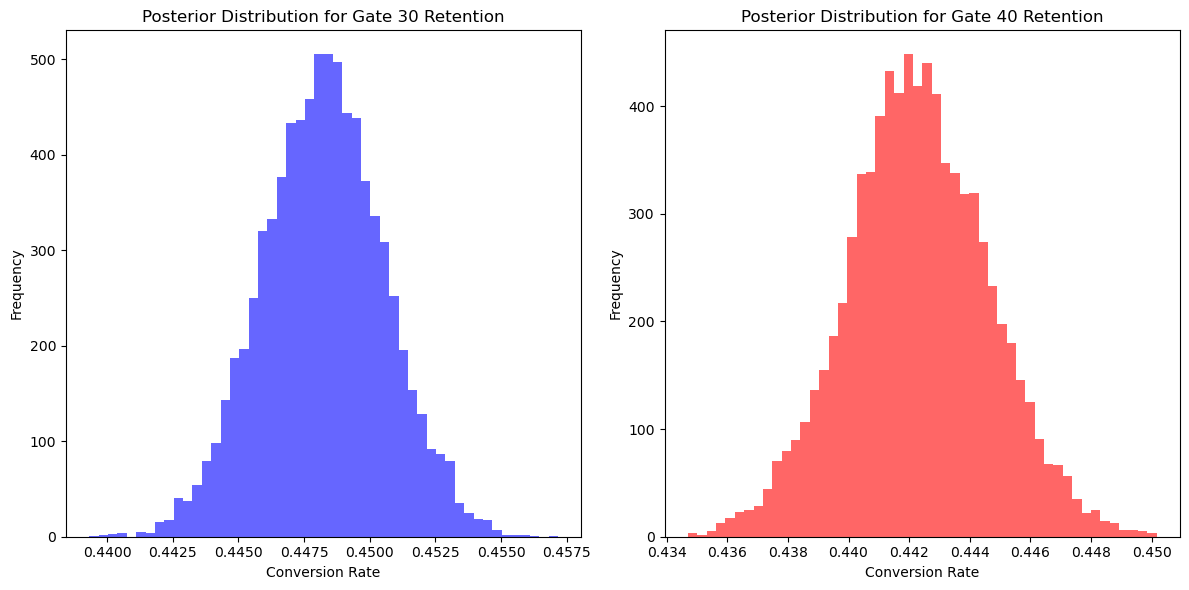

In [32]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(trace['p_gate_30'], bins=50, alpha=0.6, color='blue', label='gate_30')
plt.title('Posterior Distribution for Gate 30 Retention')
plt.xlabel('Conversion Rate')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(trace['p_gate_40'], bins=50, alpha=0.6, color='red', label='gate_40')
plt.title('Posterior Distribution for Gate 40 Retention')
plt.xlabel('Conversion Rate')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [33]:
# Calculating the probability that gate_30 performs better than gate_40
prob_gate_30_better = np.mean(trace['p_gate_30'] > trace['p_gate_40'])
print(f"Probability that gate_30 has a higher conversion rate than gate_40: {prob_gate_30_better:.4f}")

Probability that gate_30 has a higher conversion rate than gate_40: 0.9659


From the results, we find that the probability of gate_30 having a higher conversion rate than gate_40 is 96.59%. This suggests strong evidence in favor of gate_30 outperforming gate_40 in terms of user retention, with a high degree of certainty.

#### For seven day retention period

In [6]:
gate_30_retained = data[data['version'] == 'gate_30']['retention_7'].sum()
gate_30_total = len(data[data['version'] == 'gate_30'])

gate_40_retained = data[data['version'] == 'gate_40']['retention_7'].sum()
gate_40_total = len(data[data['version'] == 'gate_40'])

# Setting priors: Uniform distributions for conversion rates (0 to 1)
with pm.Model() as model:
    p_gate_30 = pm.Beta('p_gate_30', alpha=1, beta=1)  
    p_gate_40 = pm.Beta('p_gate_40', alpha=1, beta=1)  
    
    gate_30_obs = pm.Binomial('gate_30_obs', n=gate_30_total, p=p_gate_30, observed=gate_30_retained)
    gate_40_obs = pm.Binomial('gate_40_obs', n=gate_40_total, p=p_gate_40, observed=gate_40_retained)
    
    trace = pm.sample(2000, return_inferencedata=False)

Initializing NUTS using jitter+adapt_diag...
C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\pytensor\tensor\rewriting\elemwise.py:1023: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_gate_30, p_gate_40]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 50 seconds.


### Plotting the Posterior distribtution for each group

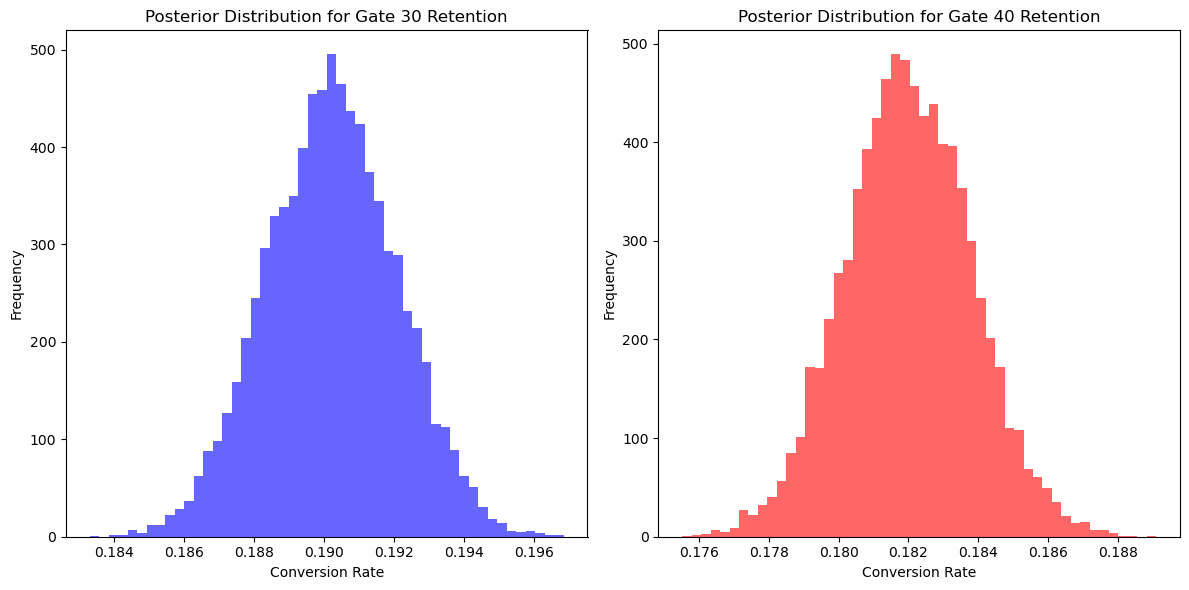

In [7]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(trace['p_gate_30'], bins=50, alpha=0.6, color='blue', label='gate_30')
plt.title('Posterior Distribution for Gate 30 Retention')
plt.xlabel('Conversion Rate')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(trace['p_gate_40'], bins=50, alpha=0.6, color='red', label='gate_40')
plt.title('Posterior Distribution for Gate 40 Retention')
plt.xlabel('Conversion Rate')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [8]:
# Calculating the probability that gate_30 performs better than gate_40
prob_gate_30_better = np.mean(trace['p_gate_30'] > trace['p_gate_40'])
print(f"Probability that gate_30 has a higher conversion rate than gate_40: {prob_gate_30_better:.4f}")

Probability that gate_30 has a higher conversion rate than gate_40: 0.9995


From the results, we find that the probability of gate_30 having a higher conversion rate than gate_40 is 99.95%. This suggests strong evidence in favor of gate_30 outperforming gate_40 in terms of user retention, with a high degree of certainty. This is even stronger than the probability obtained in case of A/B testing periods for one day retention periods.

## Conclusion

The results indicate strong evidence that 7-day retention is higher when the gate is set at level 30 compared to level 40. This suggests that to maintain high retention rates—both for the first day and the first week—it would be unwise to shift the gate from level 30 to level 40. While additional metrics, such as the number of game rounds played or in-game purchase behavior across the A/B groups, could provide further insights, retention remains a critical factor. Without retaining players, their in-game spending becomes irrelevant.

Why does retention improve when the gate is placed earlier? One might assume the opposite—that a later obstacle would keep players engaged for a longer period. However, the data suggests otherwise. One possible explanation lies in the concept of hedonic adaptation, which describes how continuous engagement in an enjoyable activity can gradually reduce the pleasure derived from it. By introducing a gate earlier, players are forced to take a break, potentially extending their enjoyment of the game. In contrast, when the gate is set at level 40, fewer players reach it, and many may lose interest and stop playing before they get there.